In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings

In [ ]:
import pandas as pd

# Step 1: Load file (it's actually CSV)
df = pd.read_csv('E:/College_Project/nhanes_diabetes_clean.xls', header=None)

# Step 2: Split the single column into multiple columns
df = df[0].str.split(',', expand=True)

# Step 3: Set first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Step 5: Convert to numeric
cols = [
    'RIDAGEYR',
    'RIAGENDR',
    'BMXBMI',
    'SBP_mean',
    'DBP_mean',
    'LBXGLU',
    'LBXGH',
    'diabetes_label'
]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 6: Check result
print("Shape:", df.shape)
print(df.head())
print(df.columns)

Shape: (67201, 12)
0     SEQN  RIDAGEYR  RIAGENDR RIDRETH3 DMDEDUC2 INDFMPIR  BMXBMI    SBP_mean  \
0  31128.0      11.0       2.0                       0.77   17.45  100.000000   
1  31129.0      15.0       1.0                       2.71   26.53  106.000000   
2  31130.0      85.0       2.0               4.0     1.99     NaN         NaN   
3  31131.0      44.0       2.0               4.0     4.65   30.90  139.333333   
4  31132.0      70.0       1.0               5.0      5.0   24.74  130.666667   

0   DBP_mean  LBXGH  LBXGLU  diabetes_label  
0  62.000000    NaN     NaN             0.0  
1  72.666667    5.2     NaN             0.0  
2        NaN    NaN     NaN             0.0  
3  73.333333    6.0    90.0             0.0  
4  57.333333    7.1   157.0             1.0  
Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR',
       'BMXBMI', 'SBP_mean', 'DBP_mean', 'LBXGH', 'LBXGLU', 'diabetes_label'],
      dtype='object', name=0)


In [ ]:
df.sample(5)

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,SBP_mean,DBP_mean,LBXGH,LBXGLU,diabetes_label
63294,98909.0,68.0,1.0,2.0,3.0,0.52,25.90,94.666667,65.333333,5.5,104.0,0.0
4331,35702.0,14.0,1.0,,,3.1,21.67,114.000000,42.000000,5.3,NaN,0.0
8925,40537.0,3.0,1.0,,,0.5,14.99,NaN,NaN,NaN,NaN,0.0
39929,74576.0,73.0,2.0,3.0,2.0,1.38,31.90,142.666667,54.000000,5.8,NaN,0.0
11051,42768.0,80.0,1.0,,2.0,1.92,43.28,96.000000,56.000000,6.0,111.0,0.0


In [ ]:
df.isnull().sum()

0
SEQN                  0
RIDAGEYR              0
RIAGENDR              0
RIDRETH3              0
DMDEDUC2              0
INDFMPIR              0
BMXBMI             5563
SBP_mean          16067
DBP_mean          16067
LBXGH             22192
LBXGLU            45509
diabetes_label        0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67201 entries, 0 to 67200
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SEQN            67201 non-null  object 
 1   RIDAGEYR        67201 non-null  float64
 2   RIAGENDR        67201 non-null  float64
 3   RIDRETH3        67201 non-null  object 
 4   DMDEDUC2        67201 non-null  object 
 5   INDFMPIR        67201 non-null  object 
 6   BMXBMI          61638 non-null  float64
 7   SBP_mean        51134 non-null  float64
 8   DBP_mean        51134 non-null  float64
 9   LBXGH           45009 non-null  float64
 10  LBXGLU          21692 non-null  float64
 11  diabetes_label  67201 non-null  float64
dtypes: float64(8), object(4)
memory usage: 6.2+ MB


In [ ]:
def preprocess_data(df):
    print("Preprocessing NHANES data...")
    
    feature_mapping = {
        'RIDAGEYR': 'Age',
        'RIAGENDR': 'Gender', 
        'BMXBMI': 'BMI',
        'SBP_mean': 'Systolic_BP',   
        'DBP_mean': 'Diastolic_BP',  
        'LBXGLU': 'Glucose',
        'LBXGH': 'HbA1c',
        'diabetes_label': 'Diabetes'  
    }
    
    df_renamed = df.rename(columns=feature_mapping)
    
    print(f"Missing values before imputation:\n{df_renamed.isnull().sum()}")

    # Step 1: Drop rows where BOTH HbA1c and Glucose missing
    before = len(df_renamed)
    df_renamed = df_renamed[
        ~(df_renamed['HbA1c'].isna() & df_renamed['Glucose'].isna())
    ]
    print(f"Dropped {before - len(df_renamed)} rows where both HbA1c and Glucose were missing")

    # Step 2: Impute Glucose from HbA1c
    glucose_missing = df_renamed['Glucose'].isna() & df_renamed['HbA1c'].notna()
    df_renamed.loc[glucose_missing, 'Glucose'] = (
        26.89 * df_renamed.loc[glucose_missing, 'HbA1c']
    ) - 45.54
    print(f"Imputed Glucose for {glucose_missing.sum()} rows using HbA1c")

    # Step 3: Median impute remaining
    for column in ['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'HbA1c']:
        if df_renamed[column].isna().any():
            df_renamed[column] = df_renamed[column].fillna(
                df_renamed[column].median()
            )
            print(f"Filled '{column}' remaining gaps with median")

    feature_names = [
        'Age', 'Gender', 'BMI', 
        'Systolic_BP', 'Diastolic_BP', 'Glucose', 'HbA1c'
    ]
    
    required_columns = feature_names + ['Diabetes']
    missing_columns = [f for f in required_columns if f not in df_renamed.columns]
    if missing_columns:
        raise KeyError(f"Critical Error: Missing required columns: {missing_columns}.")
    
    X = df_renamed[feature_names]
    y = df_renamed['Diabetes'].astype(int)

    print(f"Features: {feature_names}")
    print(f"Target distribution:\n{y.value_counts()}")
    print("\nFeature Statistics:")
    print(X.describe())
    
    return X, y, feature_names

In [ ]:
def train_model(X, y, feature_names):
    print("Training Random Forest model...")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    

    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)
    

    print("Performing hyperparameter tuning (Grid Search)...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    
    rf = RandomForestClassifier(random_state=42, class_weight = 'balanced')
    grid_search = GridSearchCV(
    rf, param_grid, cv=3, scoring='roc_auc', n_jobs=1, verbose=1
)
    
    grid_search.fit(X_train_scaled_df, y_train)
    
    
    best_model = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV ROC AUC score: {grid_search.best_score_:.4f}")
    
    model = RandomForestClassifier(**grid_search.best_params_, random_state=42, class_weight = 'balanced')
    model.fit(X_train_scaled_df, y_train)
    
    y_pred_proba = model.predict_proba(X_test_scaled_df)[:, 1]
    threshold = 0.5  # adjust if needed
    y_pred = (y_pred_proba >= threshold).astype(int)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nModel Performance on Test Set:")
    print(f"Testing Accuracy: {model.score(X_test_scaled_df, y_test):.4f}")
    print(f"Test ROC AUC: {roc_auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    
    return model, scaler, X_test_scaled_df, y_test, feature_names, X_train_scaled_df, y_pred, y_pred_proba

In [ ]:
def create_shap_explainer(model, X_train_scaled_df):
    print("Creating SHAP explainer and plot...")
    
    try:
        explainer = shap.TreeExplainer(model)
        
        sample_size = min(500, len(X_train_scaled_df))
        X_sample = X_train_scaled_df.sample(n=sample_size, random_state=42)
        
        shap_values = explainer.shap_values(X_sample)
        
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values[1], X_sample, show=False)
        plt.title("SHAP Global Feature Importance (Positive Class)")
        plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
        print("SHAP Summary Plot saved as 'shap_summary_plot.png'")
        
        return explainer
        
    except Exception as e:
        print(f"creating SHAP explainer")
        return None

def plot_feature_importance(model, feature_names, save_path='feature_importance.png'):
    print("Creating feature importance plot...")
    
    importance = model.feature_importances_
    feature_series = pd.Series(importance, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importance - Random Forest")
    feature_series.plot(kind='bar')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Importance Score')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Feature Importance Plot saved as '{save_path}'")
    
    print("\nFeature Importance (Top 5):")
    print(feature_series.head().to_string())

def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
    print("Creating confusion matrix...")
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
                yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Confusion Matrix saved as '{save_path}'")

def plot_roc_curve(y_true, y_pred_proba, save_path='roc_curve.png'):
    print("Creating ROC curve...")
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"ROC Curve saved as '{save_path}'")

In [ ]:
def save_model_artifacts(model, scaler, feature_names):
    print("Saving model artifacts...")
    
    joblib.dump(model, 'diabetes_model.pkl')
    print("- Model saved as 'diabetes_model.pkl'")
    
    joblib.dump(scaler, 'scaler.pkl')
    print("- Scaler saved as 'scaler.pkl'")
    
    with open('feature_names.json', 'w') as f:
        json.dump(feature_names, f)
    print("- Feature names saved as 'feature_names.json'")

In [ ]:
df.isnull().sum()

0
SEQN                  0
RIDAGEYR              0
RIAGENDR              0
RIDRETH3              0
DMDEDUC2              0
INDFMPIR              0
BMXBMI             5563
SBP_mean          16067
DBP_mean          16067
LBXGH             22192
LBXGLU            45509
diabetes_label        0
dtype: int64

In [ ]:
X, y, feature_names = preprocess_data(df)

Preprocessing NHANES data...
Missing values before imputation:
0
SEQN                0
Age                 0
Gender              0
RIDRETH3            0
DMDEDUC2            0
INDFMPIR            0
BMI              5563
Systolic_BP     16067
Diastolic_BP    16067
HbA1c           22192
Glucose         45509
Diabetes            0
dtype: int64
Dropped 22146 rows where both HbA1c and Glucose were missing
Imputed Glucose for 23363 rows using HbA1c
Filled 'BMI' remaining gaps with median
Filled 'Systolic_BP' remaining gaps with median
Filled 'Diastolic_BP' remaining gaps with median
Filled 'HbA1c' remaining gaps with median
Features: ['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Glucose', 'HbA1c']
Target distribution:
Diabetes
0    38625
1     6430
Name: count, dtype: int64

Feature Statistics:
0               Age        Gender           BMI   Systolic_BP  Diastolic_BP  \
count  45055.000000  45055.000000  45055.000000  45055.000000  45055.000000   
mean      43.018799      1.51084

In [ ]:
model, scaler, X_test, y_test, feature_names, X_train_scaled_df, y_pred, y_pred_proba = train_model(X, y, feature_names)

Training Random Forest model...
Performing hyperparameter tuning (Grid Search)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC AUC score: 0.9721

Model Performance on Test Set:
Testing Accuracy: 0.9585
Test ROC AUC: 0.9761

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7725
           1       0.85      0.86      0.86      1286

    accuracy                           0.96      9011
   macro avg       0.91      0.92      0.92      9011
weighted avg       0.96      0.96      0.96      9011



In [ ]:
explainer = create_shap_explainer(model, X_train_scaled_df)

Creating SHAP explainer and plot...
creating SHAP explainer


<Figure size 1000x600 with 0 Axes>

Creating confusion matrix...
Confusion Matrix saved as 'confusion_matrix.png'
Creating ROC curve...
ROC Curve saved as 'roc_curve.png'


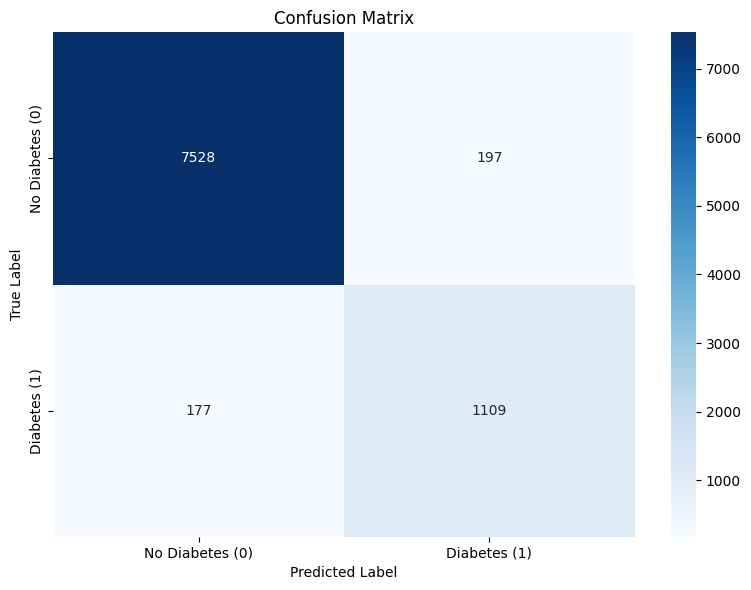

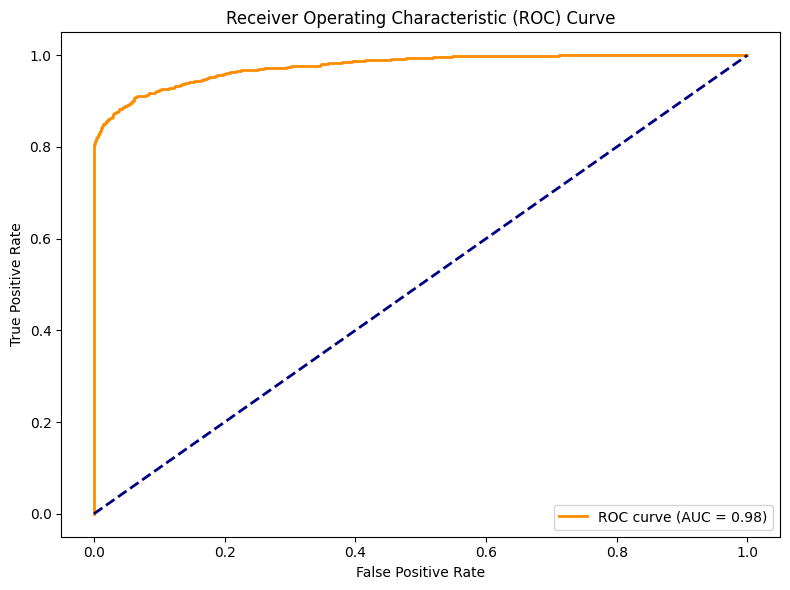

In [ ]:
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred_proba)

In [ ]:
save_model_artifacts(model, scaler, feature_names)

Saving model artifacts...
- Model saved as 'diabetes_model.pkl'
- Scaler saved as 'scaler.pkl'
- Feature names saved as 'feature_names.json'


In [ ]:
pip install sounddevice librosa scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
